In [29]:
# Célula 1: imports y configuración básica
import os
from glob import glob
import re
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape

plt.rcParams['figure.figsize'] = (10,6)

# Asume que Jupyter se lanzó desde la raíz del proyecto.
BASE = os.getcwd()
RAW = os.path.join(BASE, 'data', 'raw')
OUT = os.path.join(BASE, 'outputs')
os.makedirs(OUT, exist_ok=True)

print("BASE:", BASE)
print("RAW:", RAW)
print("OUT:", OUT)

BASE: C:\Projects\portafolio\Proyectos\01_VerdeMetria
RAW: C:\Projects\portafolio\Proyectos\01_VerdeMetria\data\raw
OUT: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs


In [30]:
# Célula 2: listar archivos ndvi_*.tif
files = sorted(glob(os.path.join(RAW, 'ndvi_*.tif')))
print("NDVI files found:", len(files))
for f in files:
    print(" ", os.path.basename(f))
files

NDVI files found: 10
  ndvi_2016_L1C.tif
  ndvi_2017_L1C.tif
  ndvi_2018.tif
  ndvi_2019.tif
  ndvi_2020.tif
  ndvi_2021.tif
  ndvi_2022.tif
  ndvi_2023.tif
  ndvi_2024.tif
  ndvi_2025.tif


['C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2016_L1C.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2017_L1C.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2018.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2019.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2020.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2021.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2022.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2023.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2024.tif',
 'C:\\Projects\\portafolio\\Proyectos\\01_VerdeMetria\\data\\raw\\ndvi_2025.tif']

Sample: ndvi_2016_L1C.tif
Shape: (1661, 2732) CRS: EPSG:32618 Transform: | 10.00, 0.00, 505460.00|
| 0.00,-10.00, 1227060.00|
| 0.00, 0.00, 1.00|
NDVI stats: -0.2847835 0.17133021 0.74647295


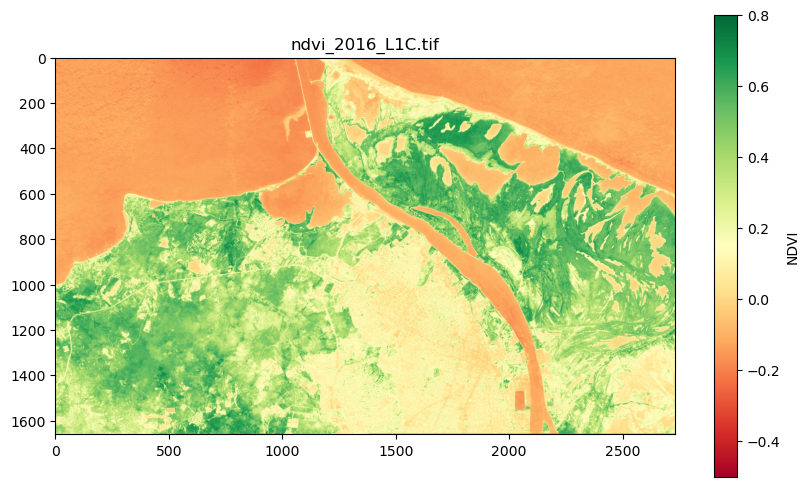

In [31]:
# Célula 3: mostrar una imagen NDVI de ejemplo
sample = files[0]  # cambia index si quieres otra
with rasterio.open(sample) as src:
    ndvi = src.read(1).astype('float32')
    meta = src.meta.copy()

print("Sample:", os.path.basename(sample))
print("Shape:", ndvi.shape, "CRS:", meta.get('crs'), "Transform:", meta.get('transform'))
print("NDVI stats:", np.nanmin(ndvi), np.nanmean(ndvi), np.nanmax(ndvi))

plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.5, vmax=0.8)
plt.title(os.path.basename(sample))
plt.colorbar(label='NDVI')
plt.show()

In [32]:
# Célula 4: métricas por año y guardar CSV
def year_from_name(path):
    m = re.search(r'ndvi_(\d{4})', os.path.basename(path))
    return int(m.group(1)) if m else None

records = []
arrays = {}
metas = {}

for p in files:
    y = year_from_name(p)
    if y is None:
        continue
    with rasterio.open(p) as src:
        arr = src.read(1).astype('float32')
        meta = src.meta.copy()
    arrays[y] = arr
    metas[y] = meta
    valid = np.isfinite(arr)
    arr_valid = arr[valid]
    mean = float(np.nanmean(arr_valid)) if arr_valid.size>0 else np.nan
    std = float(np.nanstd(arr_valid)) if arr_valid.size>0 else np.nan
    pixel_area = abs(meta['transform'].a) * abs(meta['transform'].e)
    veg_mask = (arr >= 0.3) & valid
    veg_count = int(np.nansum(veg_mask))
    veg_area_ha = veg_count * pixel_area / 10000.0
    records.append({'year': y, 'mean': mean, 'std': std, 'veg_count': veg_count, 'veg_area_ha': veg_area_ha})

df_year = pd.DataFrame(records).sort_values('year').reset_index(drop=True)
csv_year = os.path.join(OUT, 'ndvi_yearly_metrics.csv')
df_year.to_csv(csv_year, index=False)
print("Saved:", csv_year)
df_year

Saved: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_yearly_metrics.csv


,year,mean,std,veg_count,veg_area_ha
0,2016,0.171330,0.263387,1660141,16601.41
1,2017,0.170936,0.317978,1820627,18206.27
2,2018,0.245788,0.489117,2154057,21540.57
3,2019,0.233944,0.358517,1937645,19376.45
4,2020,0.223882,0.360288,1917535,19175.35
5,2021,0.271413,0.405324,2113169,21131.69
6,2022,0.215001,0.258743,1954773,19547.73
7,2023,0.187890,0.231379,1762364,17623.64
8,2024,0.183641,0.224089,1735006,17350.06
9,2025,0.201041,0.243181,1896920,18969.20


In [33]:
# Célula 5: diferencias vs baseline (2016) y guardar CSV
baseline = 2016
gain_thr = 0.15
loss_thr = -0.15

if baseline not in arrays:
    print("Baseline year not found in files:", baseline)
else:
    base_arr = arrays[baseline]
    base_meta = metas[baseline]
    pixel_area = abs(base_meta['transform'].a) * abs(base_meta['transform'].e)
    diffs = []
    for y in sorted(arrays.keys()):
        if y == baseline:
            continue
        arr = arrays[y]
        if arr.shape != base_arr.shape:
            print(f"Shape mismatch {baseline} vs {y} — skipping {y}")
            continue
        diff = arr - base_arr
        gain_m2 = float(np.nansum((diff >= gain_thr) & np.isfinite(diff))) * pixel_area
        loss_m2 = float(np.nansum((diff <= loss_thr) & np.isfinite(diff))) * pixel_area
        diffs.append({'baseline': baseline, 'year': y, 'gain_m2': gain_m2, 'loss_m2': loss_m2,
                      'gain_ha': gain_m2/10000.0, 'loss_ha': loss_m2/10000.0})
    df_diff = pd.DataFrame(diffs).sort_values('year')
    csv_diff = os.path.join(OUT, f'ndvi_diffs_vs_{baseline}.csv')
    df_diff.to_csv(csv_diff, index=False)
    print("Saved:", csv_diff)
    df_diff

Saved: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_diffs_vs_2016.csv


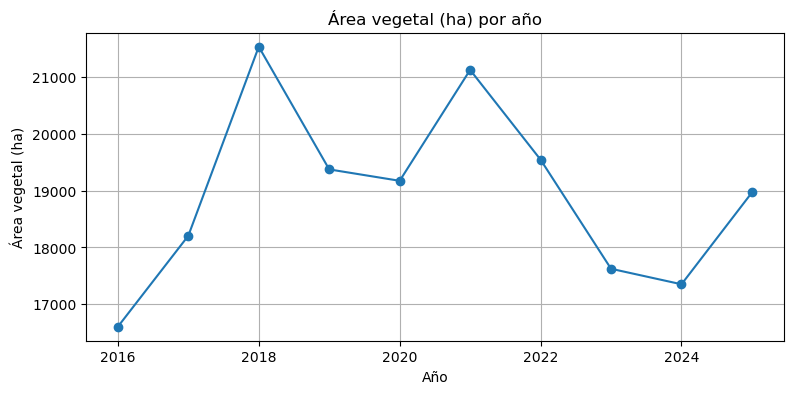

Saved: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_veg_area_trend.png


In [34]:
# Célula 6: plot de tendencia y guardar PNG
plt.figure(figsize=(9,4))
plt.plot(df_year['year'], df_year['veg_area_ha'], marker='o')
plt.title('Área vegetal (ha) por año')
plt.xlabel('Año')
plt.ylabel('Área vegetal (ha)')
plt.grid(True)
plot_path = os.path.join(OUT, 'ndvi_veg_area_trend.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", plot_path)

In [45]:
# Célula 7: generar máscaras binarias y vectorizar (guarda en GPKG)
gpkg_out = os.path.join(OUT, f'ndvi_loss_gain_vs_{baseline}.gpkg')
if baseline not in arrays:
    print("Baseline not available — skipping vectorize")
else:
    base_arr = arrays[baseline]; base_meta = metas[baseline]
    for rec in df_diff.to_dict('records'):
        y = rec['year']
        arr = arrays[y]
        if arr.shape != base_arr.shape:
            continue
        diff = arr - base_arr
        loss_mask = (diff <= loss_thr) & np.isfinite(diff)
        gain_mask = (diff >= gain_thr) & np.isfinite(diff)
        # write masks raster (optional)
        meta = base_meta.copy()
        meta.update(dtype='uint8', count=1, compress='lzw')
        loss_tif = os.path.join(OUT, f'loss_{y}_vs_{baseline}.tif')
        gain_tif = os.path.join(OUT, f'gain_{y}_vs_{baseline}.tif')
        with rasterio.open(loss_tif, 'w', **meta) as dst:
            dst.write(loss_mask.astype('uint8'), 1)
        with rasterio.open(gain_tif, 'w', **meta) as dst:
            dst.write(gain_mask.astype('uint8'), 1)
        # vectorize loss
        shapes_loss = list(features.shapes(loss_mask.astype('uint8'), mask=loss_mask.astype(bool), transform=meta['transform']))
        geoms_loss = [shape(g) for g,v in shapes_loss if int(v)==1]
        if geoms_loss:
            gdf_loss = gpd.GeoDataFrame({'year':[y]*len(geoms_loss), 'type':['loss']*len(geoms_loss)}, geometry=geoms_loss, crs=meta['crs'])
            gdf_loss.to_file(gpkg_out, layer=f'loss_{y}', driver='GPKG')
        # vectorize gain
        shapes_gain = list(features.shapes(gain_mask.astype('uint8'), mask=gain_mask.astype(bool), transform=meta['transform']))
        geoms_gain = [shape(g) for g,v in shapes_gain if int(v)==1]
        if geoms_gain:
            gdf_gain = gpd.GeoDataFrame({'year':[y]*len(geoms_gain), 'type':['gain']*len(geoms_gain)}, geometry=geoms_gain, crs=meta['crs'])
            gdf_gain.to_file(gpkg_out, layer=f'gain_{y}', driver='GPKG')

    print("Saved vector layers to:", gpkg_out)

Saved vector layers to: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_loss_gain_vs_2016.gpkg


In [36]:
# Generar PNGs coloreados desde máscaras raster (loss/gain)
import os
from glob import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from PIL import Image

OUT = "outputs"
RAW = "data/raw"

# Busca máscaras en outputs (las generadas por la celda 7)
mask_files = sorted(glob(os.path.join(OUT, "loss_*_vs_*.tif")) + glob(os.path.join(OUT, "gain_*_vs_*.tif")))
print("Found masks:", len(mask_files))

for fp in mask_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    with rasterio.open(fp) as src:
        arr = src.read(1)  # uint8 0/1 mask
        profile = src.profile

    # Crea imagen RGBA: fondo transparente (0), máscara en color
    h, w = arr.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)

    if name.startswith("loss_"):
        color = (220, 40, 40)   # rojo
    else:
        color = (40, 180, 40)   # verde

    mask = (arr == 1)
    rgba[..., 0][mask] = color[0]
    rgba[..., 1][mask] = color[1]
    rgba[..., 2][mask] = color[2]
    rgba[..., 3][mask] = 200   # alpha semi-transparente (0-255)

    out_png = os.path.join(OUT, f"preview_{name}.png")
    Image.fromarray(rgba).save(out_png)
    print("Saved:", out_png)

Found masks: 18
Saved: outputs\preview_gain_2017_vs_2016.png
Saved: outputs\preview_gain_2018_vs_2016.png
Saved: outputs\preview_gain_2019_vs_2016.png
Saved: outputs\preview_gain_2020_vs_2016.png
Saved: outputs\preview_gain_2021_vs_2016.png
Saved: outputs\preview_gain_2022_vs_2016.png
Saved: outputs\preview_gain_2023_vs_2016.png
Saved: outputs\preview_gain_2024_vs_2016.png
Saved: outputs\preview_gain_2025_vs_2016.png
Saved: outputs\preview_loss_2017_vs_2016.png
Saved: outputs\preview_loss_2018_vs_2016.png
Saved: outputs\preview_loss_2019_vs_2016.png
Saved: outputs\preview_loss_2020_vs_2016.png
Saved: outputs\preview_loss_2021_vs_2016.png
Saved: outputs\preview_loss_2022_vs_2016.png
Saved: outputs\preview_loss_2023_vs_2016.png
Saved: outputs\preview_loss_2024_vs_2016.png
Saved: outputs\preview_loss_2025_vs_2016.png


In [37]:
# Overlay: NDVI base (grayscale/color) + máscara semitransparente
import os
from glob import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from PIL import Image

BASE_YEAR = 2016
OUT = "outputs"
RAW = "data/raw"
ndvi_base_path = None

# Busca NDVI base (acepta sufijos)
for candidate in glob(os.path.join(RAW, f"ndvi_{BASE_YEAR}*.tif")):
    ndvi_base_path = candidate
    break

if ndvi_base_path is None:
    raise SystemExit(f"No NDVI base found for {BASE_YEAR} in {RAW}")

with rasterio.open(ndvi_base_path) as src:
    ndvi = src.read(1).astype('float32')
    transform = src.transform

# Normaliza NDVI a 0..255 para visualización
ndvi_valid = np.isfinite(ndvi)
ndvi_vis = np.zeros_like(ndvi, dtype=np.uint8)
ndmi = np.nanpercentile(ndvi[ndvi_valid], 2) if ndvi_valid.any() else -0.5
ndma = np.nanpercentile(ndvi[ndvi_valid], 98) if ndvi_valid.any() else 0.8
# map ndvi_min..ndvi_max -> 0..255
scale = (ndvi - ndmi) / (ndma - ndmi + 1e-9)
scale = np.clip(scale, 0, 1)
ndvi_vis[ndvi_valid] = (scale[ndvi_valid] * 255).astype(np.uint8)
# Convertir a RGB (colormap)
cmap = plt.get_cmap('RdYlGn')  # buen colormap para NDVI
rgb_ndvi = (cmap(ndvi_vis / 255.0)[:, :, :3] * 255).astype(np.uint8)

# Process masks and overlay
mask_files = sorted(glob(os.path.join(OUT, "loss_*_vs_*.tif")) + glob(os.path.join(OUT, "gain_*_vs_*.tif")))
for fp in mask_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    with rasterio.open(fp) as src:
        mask = src.read(1).astype(bool)
    # Si shape difiere, intenta reproject/resample simple: aquí asumimos mismas dimensiones
    if mask.shape != ndvi.shape:
        print("Shape mismatch:", name, "skipping overlay")
        continue

    overlay = rgb_ndvi.copy()
    if name.startswith("loss_"):
        color = np.array([220, 40, 40], dtype=np.uint8)
    else:
        color = np.array([40, 180, 40], dtype=np.uint8)

    alpha = 0.5
    overlay[mask] = (overlay[mask] * (1 - alpha) + color * alpha).astype(np.uint8)

    out_png = os.path.join(OUT, f"overlay_{name}.png")
    Image.fromarray(overlay).save(out_png)
    print("Saved:", out_png)

Saved: outputs\overlay_gain_2017_vs_2016.png
Saved: outputs\overlay_gain_2018_vs_2016.png
Saved: outputs\overlay_gain_2019_vs_2016.png
Saved: outputs\overlay_gain_2020_vs_2016.png
Saved: outputs\overlay_gain_2021_vs_2016.png
Saved: outputs\overlay_gain_2022_vs_2016.png
Saved: outputs\overlay_gain_2023_vs_2016.png
Saved: outputs\overlay_gain_2024_vs_2016.png
Saved: outputs\overlay_gain_2025_vs_2016.png
Saved: outputs\overlay_loss_2017_vs_2016.png
Saved: outputs\overlay_loss_2018_vs_2016.png
Saved: outputs\overlay_loss_2019_vs_2016.png
Saved: outputs\overlay_loss_2020_vs_2016.png
Saved: outputs\overlay_loss_2021_vs_2016.png
Saved: outputs\overlay_loss_2022_vs_2016.png
Saved: outputs\overlay_loss_2023_vs_2016.png
Saved: outputs\overlay_loss_2024_vs_2016.png
Saved: outputs\overlay_loss_2025_vs_2016.png


In [38]:
# CELDA: limpiar máscaras, vectorizar y guardar GPKG + CSV con areas
import os
from glob import glob
import rasterio
import numpy as np
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
from skimage.morphology import remove_small_objects

OUT = os.path.join(os.getcwd(), 'outputs')
gpkg_path = os.path.join(OUT, 'ndvi_loss_gain_vs_2016_cleaned.gpkg')
min_area_ha = 0.01   # mínimo área para conservar (hectáreas). Ajusta: 0.01 = 100 m²
min_area_m2 = min_area_ha * 10000.0

# Encuentra máscaras generadas (loss/gain)
mask_files = sorted(glob(os.path.join(OUT, 'loss_*_vs_*.tif')) + glob(os.path.join(OUT, 'gain_*_vs_*.tif')))
if not mask_files:
    raise SystemExit("No mask files found in outputs. Ejecuta la celda que genera máscaras primero.")

# Limpia fichero GPKG existente
if os.path.exists(gpkg_path):
    os.remove(gpkg_path)
print("Saving layers to:", gpkg_path)

rows = []
for fp in mask_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    kind = 'loss' if name.startswith('loss_') else 'gain'
    year_match = re.search(r'ndvi_(\d{4})', name)
    # extract year (mask filename like loss_2020_vs_2016.tif or gain_2021_vs_2016.tif)
    m = re.search(r'_(\d{4})_vs_', name)
    year = int(m.group(1)) if m else None

    with rasterio.open(fp) as src:
        mask = src.read(1).astype(bool)
        meta = src.meta.copy()
        transform = meta['transform']
        crs = meta['crs']
        pixel_area = abs(transform.a) * abs(transform.e)

    # remove very small objects (in pixel units): convert min_area_m2 -> min_pixels
    min_pixels = int(np.ceil(min_area_m2 / pixel_area))
    if min_pixels <= 0:
        min_pixels = 1

    cleaned = remove_small_objects(mask, min_size=min_pixels, connectivity=1)
    # vectorize cleaned mask
    shapes = features.shapes(cleaned.astype('uint8'), mask=cleaned.astype(bool), transform=transform)
    geoms = []
    areas_ha = []
    for geom, val in shapes:
        if int(val) != 1:
            continue
        geom_shp = shape(geom)
        area_m2 = geom_shp.area  # in units of CRS (meters) because CRS is metric EPSG:32618
        area_ha = area_m2 / 10000.0
        if area_ha < min_area_ha:
            continue
        geoms.append(geom_shp)
        areas_ha.append(area_ha)

    if not geoms:
        print(f"No polygons > {min_area_ha} ha for {name} (skipped).")
        continue

    gdf = gpd.GeoDataFrame({'year':[year]*len(geoms), 'type':[kind]*len(geoms), 'area_ha':areas_ha}, geometry=geoms, crs=crs)
    layer_name = f'{kind}_{year}'
    gdf.to_file(gpkg_path, layer=layer_name, driver='GPKG')
    print("Saved layer", layer_name, "with", len(gdf), "polygons")
    rows.append({'layer': layer_name, 'count': len(gdf), 'total_area_ha': sum(areas_ha)})

# resumen CSV
import pandas as pd
df_summary = pd.DataFrame(rows)
csv_summary = os.path.join(OUT, 'ndvi_loss_gain_vs_2016_summary.csv')
df_summary.to_csv(csv_summary, index=False)
print("Summary saved:", csv_summary)
df_summary

Saving layers to: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_loss_gain_vs_2016_cleaned.gpkg
Saved layer gain_2017 with 14221 polygons
Saved layer gain_2018 with 20217 polygons
Saved layer gain_2019 with 21971 polygons
Saved layer gain_2020 with 23310 polygons
Saved layer gain_2021 with 19976 polygons
Saved layer gain_2022 with 24441 polygons
Saved layer gain_2023 with 19377 polygons
Saved layer gain_2024 with 23520 polygons
Saved layer gain_2025 with 24468 polygons
Saved layer loss_2017 with 16902 polygons
Saved layer loss_2018 with 11204 polygons
Saved layer loss_2019 with 8832 polygons
Saved layer loss_2020 with 11908 polygons
Saved layer loss_2021 with 11013 polygons
Saved layer loss_2022 with 8527 polygons
Saved layer loss_2023 with 12398 polygons
Saved layer loss_2024 with 13475 polygons
Saved layer loss_2025 with 11444 polygons
Summary saved: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_loss_gain_vs_2016_summary.csv


,layer,count,total_area_ha
0,gain_2017,14221,3113.06
1,gain_2018,20217,18888.73
2,gain_2019,21971,11243.74
3,gain_2020,23310,11017.33
4,gain_2021,19976,17466.19
5,gain_2022,24441,4959.81
6,gain_2023,19377,2785.91
7,gain_2024,23520,2910.05
8,gain_2025,24468,3938.64
9,loss_2017,16902,1184.44


In [46]:
# CELDA CORREGIDA (usa fiona directamente y maneja errores)
import os
from glob import glob
import rasterio
from rasterio.warp import transform_bounds
import geopandas as gpd
import folium

# import fiona explícito para listar capas
try:
    import fiona
except Exception as e:
    raise SystemExit("Fiona no está disponible en este kernel. Instálala con conda install -n ndvi -c conda-forge fiona") from e

BASE = os.getcwd()
RAW = os.path.join(BASE, 'data', 'raw')
OUT = os.path.join(BASE, 'outputs')
gpkg = os.path.join(OUT, 'ndvi_loss_gain_vs_2016_cleaned.gpkg')

# comprueba que el GPKG existe
if not os.path.exists(gpkg):
    print("GeoPackage no encontrado:", gpkg)
else:
    print("GeoPackage encontrado:", gpkg)

# crea mapa centrado en Barranquilla
m = folium.Map(location=[11.0, -74.85], zoom_start=11, tiles='CartoDB positron')

# encontrar NDVI base desde RAW
ndvi_base_candidates = sorted(glob(os.path.join(RAW, 'ndvi_2016*.tif')))
if not ndvi_base_candidates:
    raise SystemExit(f"No se encontró NDVI base 2016 en {RAW}")
ndvi_base_path = ndvi_base_candidates[0]

# calcular bounds en EPSG:4326 para usar en ImageOverlay
with rasterio.open(ndvi_base_path) as src:
    src_bounds = src.bounds
    src_crs = src.crs
    west, south, east, north = transform_bounds(src_crs, 'EPSG:4326', src_bounds.left, src_bounds.bottom, src_bounds.right, src_bounds.top)

# añadir overlay PNG (si existen)
overlay_pngs = sorted(glob(os.path.join(OUT, 'overlay_*_vs_*.png')))
if overlay_pngs:
    overlay_img = overlay_pngs[-1]
    folium.raster_layers.ImageOverlay(
        name=os.path.basename(overlay_img),
        image=overlay_img,
        bounds=[[south, west], [north, east]],
        opacity=0.7,
        interactive=True,
        cross_origin=False,
        zindex=1
    ).add_to(m)
    print("Added overlay:", overlay_img)
else:
    print("No overlay PNGs found in", OUT)

# añadir vectores desde GeoPackage usando fiona.listlayers
if os.path.exists(gpkg):
    try:
        layers = fiona.listlayers(gpkg)
        print("Layers in GPKG:", layers)
    except Exception as e:
        raise SystemExit("Error listando capas con fiona.listlayers: " + str(e)) from e

    for layer in layers:
        try:
            gdf = gpd.read_file(gpkg, layer=layer)
        except Exception as e:
            print(f"Error leyendo layer {layer}: {e}")
            continue
        # convertir a EPSG:4326 antes de pasar a folium
        try:
            gdf_4326 = gdf.to_crs(epsg=4326)
        except Exception as e:
            print(f"Warning converting layer {layer} to EPSG:4326:", e)
            continue
        color = 'red' if 'loss' in layer.lower() else 'green'
        folium.GeoJson(
            gdf_4326.__geo_interface__,
            name=layer,
            style_function=lambda feat, color=color: {'color': color, 'weight': 1, 'fillOpacity': 0.4}
        ).add_to(m)
else:
    print("No GPKG found at:", gpkg)

folium.LayerControl().add_to(m)
map_out = os.path.join(OUT, 'ndvi_interactive_map.html')
m.save(map_out)
print("Map saved:", map_out)

GeoPackage encontrado: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_loss_gain_vs_2016_cleaned.gpkg
Added overlay: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\overlay_loss_2025_vs_2016.png
Layers in GPKG: ['gain_2017', 'gain_2018', 'gain_2019', 'gain_2020', 'gain_2021', 'gain_2022', 'gain_2023', 'gain_2024', 'gain_2025', 'loss_2017', 'loss_2018', 'loss_2019', 'loss_2020', 'loss_2021', 'loss_2022', 'loss_2023', 'loss_2024', 'loss_2025']
Map saved: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\ndvi_interactive_map.html


In [55]:
from IPython.display import IFrame
# usa '/files/...' (nota la barra inicial)
display(IFrame('/files/outputs/ndvi_interactive_map.html', width=900, height=600))

In [58]:
# Celda 1: listar capas en data/ancillary/gadm41_COL.gpkg
import os
fro
m glob import glob
import fiona

anc = os.path.join(os.getcwd(), 'data', 'ancillary')
gpkg = os.path.join(anc, 'gadm41_COL.gpkg')
print("Checking:", gpkg)
print("Exists:", os.path.exists(gpkg))
if os.path.exists(gpkg):
    layers = fiona.listlayers(gpkg)
    print("Layers found in GPKG:")
    for i, L in enumerate(layers):
        print(i, "-", L)
else:
    print("GeoPackage no encontrado en data/ancillary. Asegúrate de haberlo descargado ahí.")

Checking: C:\Projects\portafolio\Proyectos\01_VerdeMetria\data\ancillary\gadm41_COL.gpkg
Exists: True
Layers found in GPKG:
0 - ADM_ADM_0
1 - ADM_ADM_1
2 - ADM_ADM_2


In [61]:
# Celda C: intersectar masks con sectores GADM nivel 2 y guardar CSV con area por sector (m2 y ha)
import os, fiona
import geopandas as gpd
import pandas as pd

OUT = os.path.join(os.getcwd(), 'outputs')
gpkg_masks = os.path.join(OUT, 'ndvi_loss_gain_vs_2016_cleaned.gpkg')
gpkg_gadm = os.path.join(os.getcwd(), 'data', 'ancillary', 'gadm41_COL.gpkg')

# CAMBIA este campo si en la Celda A viste otro (ej. 'GID_2' o 'NAME_2')
id_field = 'NAME_2'

# seleccionar capa GADM nivel 2
layers = fiona.listlayers(gpkg_gadm)
layer_gadm = None
for L in layers:
    if L.endswith('_2') or 'ADM_ADM_2' in L:
        layer_gadm = L
        break
if layer_gadm is None:
    layer_gadm = layers[0]
print("Using GADM layer:", layer_gadm)

# reprojectar a CRS métrico para área (ajusta EPSG si usas otra UTM)
target_crs = 'EPSG:32618'

sectors = gpd.read_file(gpkg_gadm, layer=layer_gadm)
if sectors.crs is None:
    raise SystemExit("La capa GADM no tiene CRS; añade .prj o especifica el CRS.")
sectors = sectors.to_crs(target_crs)
print("Loaded sectors:", len(sectors), "CRS:", sectors.crs)

# comprobar gpkg masks
if not os.path.exists(gpkg_masks):
    raise SystemExit(f"No se encontró {gpkg_masks}. Asegúrate de haber generado las máscaras en outputs/")

mask_layers = fiona.listlayers(gpkg_masks)
print("Mask layers:", mask_layers)

rows = []
for layer in mask_layers:
    kind = 'gain' if 'gain' in layer.lower() else 'loss'
    try:
        year = int(layer.split('_')[1])
    except:
        year = None
    print("Processing:", layer, kind, year)
    masks = gpd.read_file(gpkg_masks, layer=layer).to_crs(target_crs)
    if masks.empty:
        print("  Empty masks for", layer)
        continue

    # opcional: disolver para reducir geometrías si hay demasiadas piezas (descomenta si quieres)
    # masks = masks.dissolve().explode(index_parts=False).reset_index(drop=True)

    inter = gpd.overlay(masks, sectors[[id_field,'geometry']], how='intersection')
    if inter.empty:
        print("  No intersections for", layer)
        continue
    inter['area_m2'] = inter.geometry.area
    inter['area_ha'] = inter['area_m2'] / 10000.0
    agg = inter.groupby(id_field).agg({'area_m2':'sum', 'area_ha':'sum'}).reset_index()
    agg['year'] = year; agg['kind'] = kind
    rows.append(agg)

if rows:
    df = pd.concat(rows, ignore_index=True)
    csv_out = os.path.join(OUT, 'areas_by_sector_vs_2016.csv')
    df.to_csv(csv_out, index=False)
    print("Saved summary to:", csv_out)
    display(df.sort_values(['kind','year','area_m2'], ascending=[True, True, False]).head(40))
else:
    print("No intersections produced. Revisa extents/CRS y vuelve a intentar.")

Using GADM layer: ADM_ADM_2
Loaded sectors: 1119 CRS: EPSG:32618
Mask layers: ['gain_2017', 'gain_2018', 'gain_2019', 'gain_2020', 'gain_2021', 'gain_2022', 'gain_2023', 'gain_2024', 'gain_2025', 'loss_2017', 'loss_2018', 'loss_2019', 'loss_2020', 'loss_2021', 'loss_2022', 'loss_2023', 'loss_2024', 'loss_2025']
Processing: gain_2017 gain 2017
Processing: gain_2018 gain 2018
Processing: gain_2019 gain 2019
Processing: gain_2020 gain 2020
Processing: gain_2021 gain 2021
Processing: gain_2022 gain 2022
Processing: gain_2023 gain 2023
Processing: gain_2024 gain 2024
Processing: gain_2025 gain 2025
Processing: loss_2017 loss 2017
Processing: loss_2018 loss 2018
Processing: loss_2019 loss 2019
Processing: loss_2020 loss 2020
Processing: loss_2021 loss 2021
Processing: loss_2022 loss 2022
Processing: loss_2023 loss 2023
Processing: loss_2024 loss 2024
Processing: loss_2025 loss 2025
Saved summary to: C:\Projects\portafolio\Proyectos\01_VerdeMetria\outputs\areas_by_sector_vs_2016.csv


,NAME_2,area_m2,area_ha,year,kind
3,Sitionuevo,1.130047e+07,1130.047203,2017,gain
0,Barranquilla,1.103255e+07,1103.255204,2017,gain
2,Puerto Colombia,6.716425e+06,671.642455,2017,gain
4,Tubará,2.078626e+06,207.862578,2017,gain
1,Galapa,2.511953e+02,0.025120,2017,gain
8,Sitionuevo,9.248917e+07,9248.917007,2018,gain
5,Barranquilla,5.572574e+07,5572.573581,2018,gain
7,Puerto Colombia,3.416710e+07,3416.709843,2018,gain
9,Tubará,5.775839e+06,577.583852,2018,gain
6,Galapa,7.110770e+03,0.711077,2018,gain


In [62]:
import pandas as pd
df = pd.read_csv('outputs/areas_by_sector_vs_2016.csv')
years = sorted(df['year'].unique())

for y in years:
    print("=== Año", y, " (TOP 10 ganancia) ===")
    display(df[(df['year']==y) & (df['kind']=='gain')].sort_values('area_ha', ascending=False).head(10))
    print("=== Año", y, " (TOP 10 pérdida) ===")
    display(df[(df['year']==y) & (df['kind']=='loss')].sort_values('area_ha', ascending=False).head(10))

=== Año 2017  (TOP 10 ganancia) ===


,NAME_2,area_m2,area_ha,year,kind
3,Sitionuevo,1.130047e+07,1130.047203,2017,gain
0,Barranquilla,1.103255e+07,1103.255204,2017,gain
2,Puerto Colombia,6.716425e+06,671.642455,2017,gain
4,Tubará,2.078626e+06,207.862578,2017,gain
1,Galapa,2.511953e+02,0.025120,2017,gain


=== Año 2017  (TOP 10 pérdida) ===


,NAME_2,area_m2,area_ha,year,kind
42,Barranquilla,4.234333e+06,423.433253,2017,loss
45,Sitionuevo,3.097534e+06,309.753389,2017,loss
44,Puerto Colombia,9.304452e+05,93.044523,2017,loss
46,Tubará,4.603538e+04,4.603538,2017,loss
43,Galapa,1.605817e+04,1.605817,2017,loss


=== Año 2018  (TOP 10 ganancia) ===


...

,NAME_2,area_m2,area_ha,year,kind
77,Barranquilla,1.527603e+07,1527.603193,2024,loss
79,Puerto Colombia,1.378990e+07,1378.989952,2024,loss
80,Sitionuevo,5.595926e+06,559.592577,2024,loss
81,Tubará,2.225101e+05,22.251005,2024,loss
78,Galapa,4.326514e+04,4.326514,2024,loss


=== Año 2025  (TOP 10 ganancia) ===


,NAME_2,area_m2,area_ha,year,kind
40,Sitionuevo,1.998992e+07,1998.992222,2025,gain
38,Barranquilla,1.443920e+07,1443.919965,2025,gain
39,Puerto Colombia,2.825959e+06,282.595938,2025,gain
41,Tubará,1.256940e+06,125.693963,2025,gain


=== Año 2025  (TOP 10 pérdida) ===


,NAME_2,area_m2,area_ha,year,kind
82,Barranquilla,1.049197e+07,1049.197202,2025,loss
85,Sitionuevo,5.400798e+06,540.079823,2025,loss
84,Puerto Colombia,4.893870e+06,489.387020,2025,loss
86,Tubará,2.863317e+04,2.863317,2025,loss
83,Galapa,2.812853e+04,2.812853,2025,loss


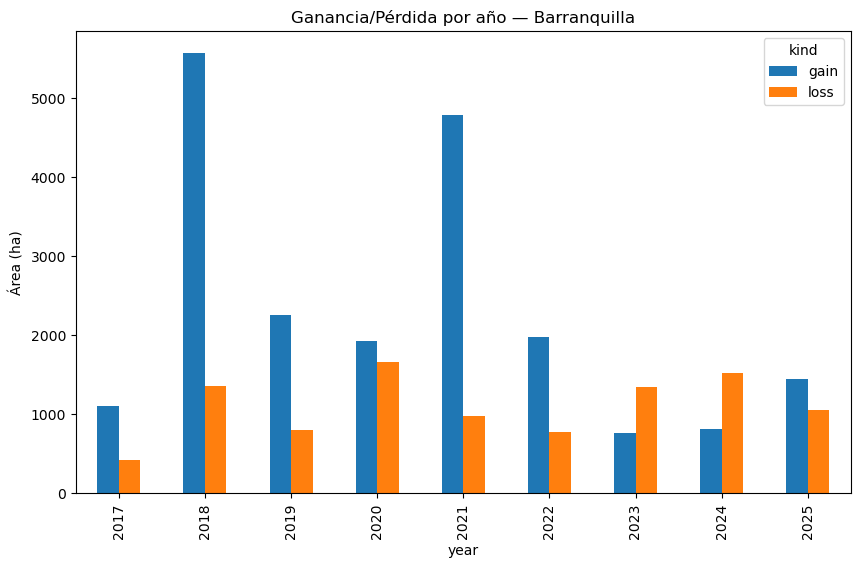

In [63]:
import matplotlib.pyplot as plt
mun = 'Barranquilla'   # cambia por el municipio que quieras
ts = df[df['NAME_2']==mun].pivot_table(index='year', columns='kind', values='area_ha', aggfunc='sum').fillna(0)
ts.plot(kind='bar', stacked=False)
plt.ylabel('Área (ha)')
plt.title(f'Ganancia/Pérdida por año — {mun}')
plt.show()

In [64]:
# prepara tabla pivot con gain y loss
pivot = df.pivot_table(index=['NAME_2','year'], columns='kind', values='area_ha', aggfunc='sum').fillna(0).reset_index()
pivot['net_ha'] = pivot.get('gain',0) - pivot.get('loss',0)
# Top net loss / net gain para un año específico (ej. 2025)
year = 2025
print("Top net gain", year)
display(pivot[pivot['year']==year].sort_values('net_ha', ascending=False).head(10))
print("Top net loss", year)
display(pivot[pivot['year']==year].sort_values('net_ha', ascending=True).head(10))

Top net gain 2025


kind,NAME_2,year,gain,loss,net_ha
35,Sitionuevo,2025,1998.992222,540.079823,1458.912399
8,Barranquilla,2025,1443.919965,1049.197202,394.722762
44,Tubará,2025,125.693963,2.863317,122.830646
17,Galapa,2025,0.000000,2.812853,-2.812853
26,Puerto Colombia,2025,282.595938,489.387020,-206.791082


Top net loss 2025


kind,NAME_2,year,gain,loss,net_ha
26,Puerto Colombia,2025,282.595938,489.387020,-206.791082
17,Galapa,2025,0.000000,2.812853,-2.812853
44,Tubará,2025,125.693963,2.863317,122.830646
8,Barranquilla,2025,1443.919965,1049.197202,394.722762
35,Sitionuevo,2025,1998.992222,540.079823,1458.912399


In [65]:
import geopandas as gpd
sectors = gpd.read_file('data/ancillary/gadm41_COL.gpkg', layer='ADM_ADM_2').to_crs('EPSG:32618')
# calcular área total de cada municipio en ha
sectors['area_m2_total'] = sectors.geometry.area
sectors['area_ha_total'] = sectors['area_m2_total'] / 10000.0
# agrega areas detectadas por municipio para el año 2025 (ejemplo)
agg_2025 = df[df['year']==2025].groupby(['NAME_2','kind']).area_ha.sum().unstack(fill_value=0).reset_index()
agg_2025['area_ha_total_detected'] = agg_2025.get('gain',0) + agg_2025.get('loss',0)  # o usar net_ha
# merge con sectors (coincidir por NAME_2)
merged = sectors.merge(agg_2025, left_on='NAME_2', right_on='NAME_2', how='left').fillna(0)
merged['pct_affected'] = (merged['area_ha_total_detected'] / merged['area_ha_total']) * 100
# mostrar top municipios por porcentaje afectado
display(merged[['NAME_2','area_ha_total','area_ha_total_detected','pct_affected']].sort_values('pct_affected', ascending=False).head(20))

,NAME_2,area_ha_total,area_ha_total_detected,pct_affected
144,Barranquilla,1.819690e+04,2493.117167,13.700778
156,Puerto Colombia,5.724925e+03,771.982957,13.484596
728,Sitionuevo,9.401286e+04,2539.072046,2.700771
164,Tubará,1.755602e+04,128.557280,0.732269
644,Puerto Colombia,1.575663e+06,771.982957,0.048994
147,Galapa,9.730704e+03,2.812853,0.028907
3,La Victoria,1.495245e+05,0.000000,0.000000
4,Leticia,6.202964e+05,0.000000,0.000000
5,Mirití-Paraná,1.694442e+06,0.000000,0.000000
6,Puerto Alegria,8.554522e+05,0.000000,0.000000


In [66]:
import folium
from folium import Choropleth

# preparar datos para 2025 (gain)
year = 2025
gain_2025 = df[(df['year']==year) & (df['kind']=='gain')].groupby('NAME_2').area_ha.sum().reset_index()
sectors_4326 = sectors.to_crs(epsg=4326)  # folium necesita lat/lon
m = folium.Map(location=[11.0, -74.85], zoom_start=10, tiles='CartoDB positron')

# merge for choropleth
chor_df = sectors_4326.merge(gain_2025, on='NAME_2', how='left').fillna(0)

Choropleth(
    geo_data=chor_df.__geo_interface__,
    data=chor_df,
    columns=['NAME_2','area_ha'],
    key_on='feature.properties.NAME_2',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=f'Gain (ha) {year}'
).add_to(m)

m.save('outputs/choropleth_gain_{}.html'.format(year))
print("Mapa guardado en outputs/choropleth_gain_{}.html".format(year))

Mapa guardado en outputs/choropleth_gain_2025.html


In [68]:
print("Pivot columns:", list(pivot.columns))
print("net_2025 columns:", list(net_2025.columns))
print("Sectors columns:", list(sectors.columns))

Pivot columns: ['NAME_2', 'year', 'gain', 'loss', 'net_ha']
net_2025 columns: ['NAME_2', 'year', 'gain', 'loss', 'net_area_ha']
Sectors columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry', 'area_m2_total', 'area_ha_total']


In [70]:
# usar net_area_ha (columna que creaste al renombrar)
gdf_out = sectors.merge(net_2025[['NAME_2','net_area_ha']], on='NAME_2', how='left').fillna(0)
# opcional: renombrar para mantener consistencia
gdf_out = gdf_out.rename(columns={'net_area_ha':'net_ha'})
gdf_out.to_file('outputs/areas_by_municipio_2025.gpkg', layer='net_2025', driver='GPKG')
gdf_out.to_file('outputs/areas_by_municipio_2025.geojson', driver='GeoJSON')
print("Exportados outputs/areas_by_municipio_2025.gpkg / .geojson")

Exportados outputs/areas_by_municipio_2025.gpkg / .geojson
